# Example data walkthrough

Load bundled FlyWire morphologies with {func}`~neurosetta.load_example_data`,
inspect a {class}`~neurosetta.api.Tree`, and plot a 2D projection.

See also {doc}`io` and the markdown tutorials {doc}`../tutorials/tree_basics`.

**Run in the browser:** [Launch on Binder](https://mybinder.org/v2/gh/NikDrummond/NeuRosetta/main?filepath=docs%2Fgetting_started%2Fexample_data.ipynb)

Re-execute before committing code changes: `python docs/_execute_notebooks.py`


In [1]:
import matplotlib.pyplot as plt
import neurosetta as nr

%matplotlib inline

print(f"neurosetta {nr.__version__}")
print(f"NR data dir: {nr.example_data_dir()}")
print(f"SWC data dir: {nr.example_data_dir(format='swc')}")


neurosetta 0.1.0
NR data dir: /home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/nr
SWC data dir: /home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/swc


In [2]:
EXAMPLE_ID = 720575940596125868

forest = nr.load_example_data()
tree = nr.load_example_data(EXAMPLE_ID)

print(forest)
print(tree)


Forest(n=4, ids=[720575940596125868, 720575940599459782, 720575940599704006, 720575940599729862])
Tree(ID=720575940596125868) with 2010 nodes


In [3]:
print("ID:", tree.ID)
print("metadata:", tree.metadata)
print("vertices:", tree.graph.num_vertices(), "edges:", tree.graph.num_edges())


ID: 720575940596125868
metadata: {'units': 'micron', 'file_path': '/home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/nr/720575940596125868.nr', 'isReduced': False, 'Neuron_type': 'T5', 'Neuron_subtype': 'c', 'Hemisphere': 'R'}
vertices: 2010 edges: 2009


In [4]:
print(f"nodes:      {tree.count_nodes()}")
print(f"branches:   {tree.count_branches()}")
print(f"leaves:     {tree.count_leaves()}")
print(f"cable len:  {tree.get_total_cable_length():.1f}")


nodes:      2010
branches:   99
leaves:     111
cable len:  404.2


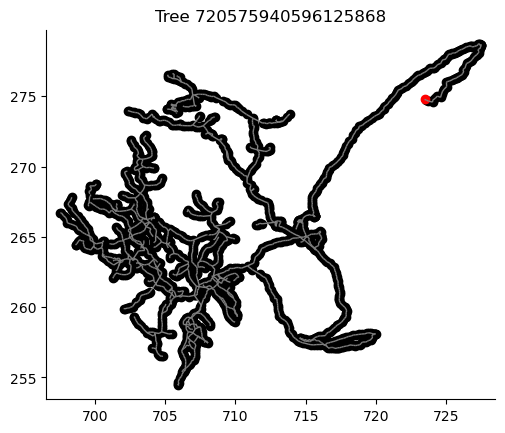

In [5]:
ax = tree.show_2d()
ax.set_title(f"Tree {tree.ID}")
plt.show()


In [6]:
import tempfile
from pathlib import Path

out = Path(tempfile.mkdtemp())
tree.set_units("nm")
tree.save_tree(out / f"{tree.ID}.nr")
reloaded = nr.load(out / f"{tree.ID}.nr")
print(reloaded.metadata.get("units"), reloaded.count_nodes())


nanometer 2010
